<a href="https://colab.research.google.com/github/kswkm/AI_Colab/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving penguins_size.csv to penguins_size.csv


In [4]:
import pandas as pd
df = pd.read_csv('/content/penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [7]:
df.dropna(inplace=True)
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [8]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [9]:
df[df['sex']=='.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [10]:
df.drop(axis=0, inplace=True, index=336)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   culmen_length_mm   333 non-null    float64
 3   culmen_depth_mm    333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [11]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


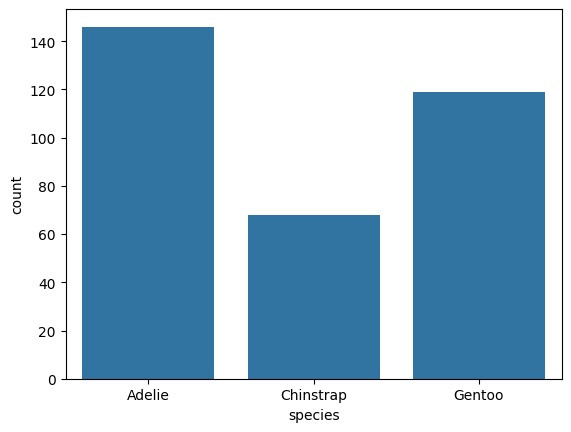

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='species', data=df)
plt.show()

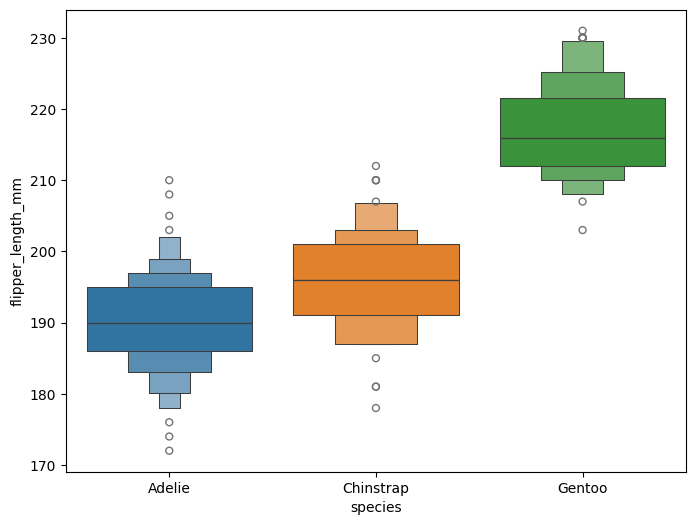

In [13]:
plt.figure(figsize=(8, 6))
sns.boxenplot(x='species', y='flipper_length_mm', hue='species', data=df)
plt.show()

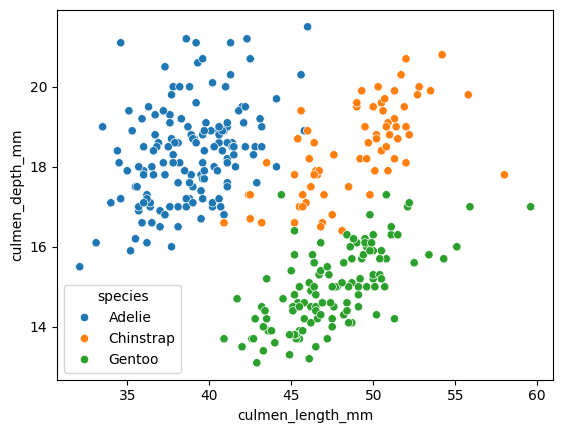

In [14]:
sns.scatterplot(x='culmen_length_mm', y='culmen_depth_mm', hue='species', data=df)
plt.show()

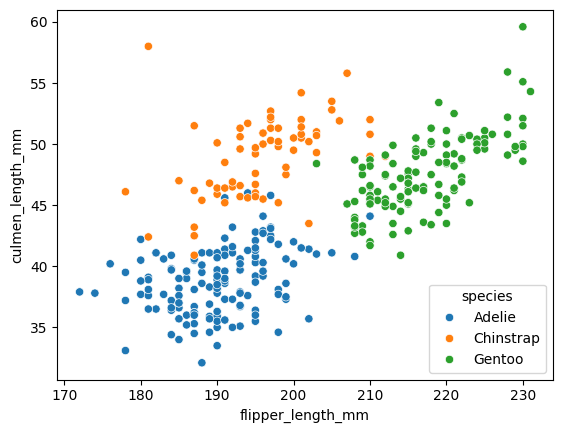

In [15]:
sns.scatterplot(x='flipper_length_mm', y='culmen_length_mm', hue='species', data=df)
plt.show()

In [31]:
dataset = df.values
X = dataset[:, :-1]
y = dataset[:, -1]

In [28]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify numerical and categorical columns in the original df (excluding the target 'sex')
numerical_features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['species', 'island']

# Create a preprocessor using ColumnTransformer
# This will apply OneHotEncoder to categorical features and MinMaxScaler to numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), [df.columns.get_loc(col) for col in categorical_features]),
        ('num', MinMaxScaler(), [df.columns.get_loc(col) for col in numerical_features])
    ],
    remainder='passthrough' # Keep other columns if any, though in this case all are handled
)

# Transform the X data
X_scaled = preprocessor.fit_transform(df.drop('sex', axis=1))
X_scaled[0]

array([1.        , 0.        , 0.        , 0.        , 0.        ,
       1.        , 0.25454545, 0.66666667, 0.15254237, 0.29166667])

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=0)

In [34]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [42]:
print("훈련 데이터를 이용한 모델 분류 정확도: ", knn.score(X_train, y_train))
print("테스트 데이터를 이용한 모델 성능 평가: ", knn.score(X_test, y_test))

훈련 데이터를 이용한 모델 분류 정확도:  0.9227467811158798
테스트 데이터를 이용한 모델 성능 평가:  0.93


In [44]:
for k in range(2, 21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  score = knn.score(X_test, y_test)
  print('k: %d, accuracy: %.2f' % (k, score*100))

k: 2, accuracy: 85.00
k: 3, accuracy: 92.00
k: 4, accuracy: 89.00
k: 5, accuracy: 94.00
k: 6, accuracy: 90.00
k: 7, accuracy: 93.00
k: 8, accuracy: 91.00
k: 9, accuracy: 92.00
k: 10, accuracy: 92.00
k: 11, accuracy: 92.00
k: 12, accuracy: 91.00
k: 13, accuracy: 91.00
k: 14, accuracy: 91.00
k: 15, accuracy: 91.00
k: 16, accuracy: 91.00
k: 17, accuracy: 91.00
k: 18, accuracy: 90.00
k: 19, accuracy: 92.00
k: 20, accuracy: 92.00


In [45]:
predictions = knn.predict(X_test)

In [46]:
print(predictions[:5])
print(y_test[:5])

['MALE' 'MALE' 'MALE' 'FEMALE' 'MALE']
['MALE' 'MALE' 'MALE' 'FEMALE' 'MALE']


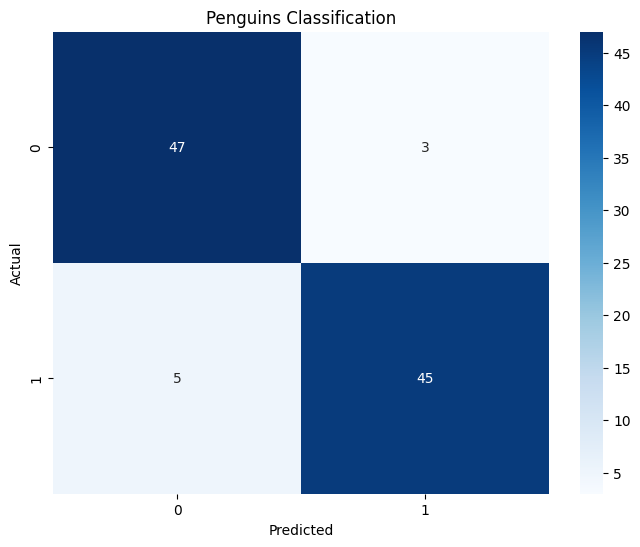

In [48]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))

conf = confusion_matrix(y_test, predictions)
sns.heatmap(conf, annot=True, cmap='Blues')

plt.title("Penguins Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
from google.colab import files
uploaded = files.upload()

Saving penguin_new.csv to penguin_new.csv


In [53]:
df_new = pd.read_csv('/content/penguin_new.csv')
df_new.head()

,culmen_depth_mm,culmen_length_mm,flipper_length_mm
0,18.7,39.1,181
1,18.5,46.9,200
2,14.5,50.0,250


In [58]:
# Original df_new has: culmen_depth_mm, culmen_length_mm, flipper_length_mm
# The preprocessor was trained on: species, island, culmen_length_mm, culmen_depth_mm, flipper_length_mm, body_mass_g

# Create a copy to avoid modifying the original df_new in place if it were used elsewhere
df_new_full = df_new.copy()

# Add placeholder columns for species, island, and body_mass_g
# In a real-world scenario, you would have actual values for these from your new data
df_new_full['species'] = 'Adelie'  # Example placeholder, choose one of the categories from training data
df_new_full['island'] = 'Torgersen' # Example placeholder
df_new_full['body_mass_g'] = 3750.0 # Example placeholder, e.g., mean/median from training data

# Ensure the columns are in the same order as the features the preprocessor was fitted on
# based on `df.drop('sex', axis=1)` columns in 'ngqC4QCH4r3R'
expected_columns_for_preprocessor = ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_new_full = df_new_full[expected_columns_for_preprocessor]

# Now, apply the preprocessor to transform the new data
# Use .transform() not .fit_transform() as the preprocessor is already fitted
new_scaled = preprocessor.transform(df_new_full)

In [59]:
print(knn.predict(new_scaled))

['FEMALE' 'MALE' 'MALE']
